In [1]:
!nvidia-smi

Mon Aug 10 19:25:13 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.309.01             Driver Version: 535.309.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Quadro GV100                   Off | 00000000:73:00.0  On |                  Off |
| 29%   40C    P0              24W / 250W |    173MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error

print("SRCNN Baseline Experiment Started")

SRCNN Baseline Experiment Started


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Using device: cuda
GPU: Quadro GV100


In [4]:
GT_PATH = "../data/train/GT"
NOISY_PATH = "../data/train/NoisyLR"

files = sorted([
    f for f in os.listdir(GT_PATH)
    if f.endswith(".npy")
])

print("Total images:", len(files))

print(
    "GT folder:",
    os.path.exists(GT_PATH)
)

print(
    "NoisyLR folder:",
    os.path.exists(NOISY_PATH)
)

Total images: 3200
GT folder: True
NoisyLR folder: True


In [5]:
sample = files[0]

gt = np.load(
    os.path.join(
        GT_PATH,
        sample
    )
)

noisy = np.load(
    os.path.join(
        NOISY_PATH,
        sample
    )
)

print("Filename:", sample)

print("GT shape:", gt.shape)
print("NoisyLR shape:", noisy.shape)

print("GT dtype:", gt.dtype)
print("Noisy dtype:", noisy.dtype)

print(
    "GT range:",
    gt.min(),
    gt.max()
)

print(
    "Noisy range:",
    noisy.min(),
    noisy.max()
)

Filename: 000000.npy
GT shape: (256, 256)
NoisyLR shape: (128, 128)
GT dtype: float32
Noisy dtype: float32
GT range: 0.0 1.0
Noisy range: -0.0026427102 1.3257757


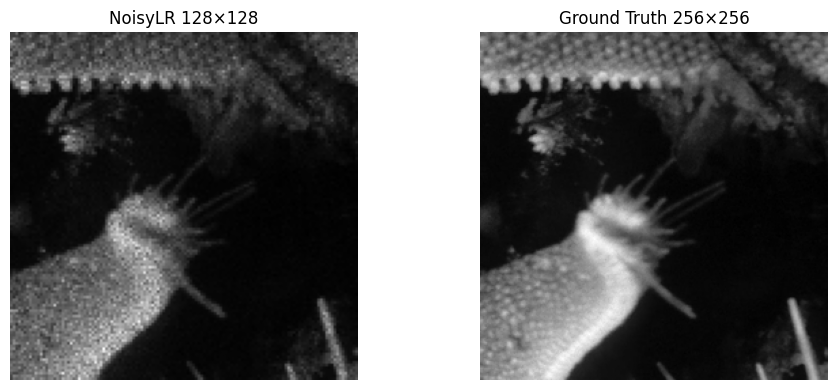

In [6]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(
    noisy,
    cmap="gray"
)

plt.title(
    "NoisyLR 128×128"
)

plt.axis("off")


plt.subplot(1,2,2)

plt.imshow(
    gt,
    cmap="gray"
)

plt.title(
    "Ground Truth 256×256"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [7]:
class SemiconductorDataset(Dataset):

    def __init__(
        self,
        gt_path,
        noisy_path,
        file_list
    ):

        self.gt_path = gt_path
        self.noisy_path = noisy_path
        self.files = file_list

    def __len__(self):

        return len(self.files)

    def __getitem__(self, idx):

        filename = self.files[idx]

        gt = np.load(
            os.path.join(
                self.gt_path,
                filename
            )
        ).astype(np.float32)

        noisy = np.load(
            os.path.join(
                self.noisy_path,
                filename
            )
        ).astype(np.float32)

        # Bicubic pre-upsampling
        noisy_up = resize(
            noisy,
            gt.shape,
            order=3,
            anti_aliasing=True,
            preserve_range=True
        ).astype(np.float32)

        # Convert to tensors
        gt = torch.from_numpy(
            gt
        ).unsqueeze(0)

        noisy_up = torch.from_numpy(
            noisy_up
        ).unsqueeze(0)

        return noisy_up, gt

In [8]:
np.random.seed(42)

indices = np.random.permutation(
    len(files)
)

train_end = int(
    0.80 * len(files)
)

val_end = int(
    0.90 * len(files)
)

train_files = [
    files[i]
    for i in indices[:train_end]
]

val_files = [
    files[i]
    for i in indices[
        train_end:val_end
    ]
]

test_files = [
    files[i]
    for i in indices[val_end:]
]

print(
    "Training images:",
    len(train_files)
)

print(
    "Validation images:",
    len(val_files)
)

print(
    "Testing images:",
    len(test_files)
)

Training images: 2560
Validation images: 320
Testing images: 320


In [9]:
train_dataset = SemiconductorDataset(
    GT_PATH,
    NOISY_PATH,
    train_files
)

val_dataset = SemiconductorDataset(
    GT_PATH,
    NOISY_PATH,
    val_files
)

test_dataset = SemiconductorDataset(
    GT_PATH,
    NOISY_PATH,
    test_files
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

Train: 2560
Validation: 320
Test: 320


In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Testing batches:",
    len(test_loader)
)

Training batches: 160
Validation batches: 20
Testing batches: 320


In [11]:
input_batch, gt_batch = next(
    iter(train_loader)
)

print(
    "SRCNN input:",
    input_batch.shape
)

print(
    "Ground Truth:",
    gt_batch.shape
)

SRCNN input: torch.Size([16, 1, 256, 256])
Ground Truth: torch.Size([16, 1, 256, 256])


In [12]:
class SRCNN(nn.Module):

    def __init__(self):

        super(SRCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            1,
            64,
            kernel_size=9,
            padding=4
        )

        self.conv2 = nn.Conv2d(
            64,
            32,
            kernel_size=5,
            padding=2
        )

        self.conv3 = nn.Conv2d(
            32,
            1,
            kernel_size=5,
            padding=2
        )

        self.relu = nn.ReLU(
            inplace=True
        )

    def forward(self, x):

        x = self.relu(
            self.conv1(x)
        )

        x = self.relu(
            self.conv2(x)
        )

        x = self.conv3(x)

        return x

In [13]:
model = SRCNN().to(device)

print(model)

SRCNN(
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU(inplace=True)
)


In [14]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    total_params
)

print(
    "Trainable parameters:",
    trainable_params
)

Total parameters: 57281
Trainable parameters: 57281


In [15]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss: MSE")
print("Optimizer: Adam")
print("Learning Rate: 0.0001")

Loss: MSE
Optimizer: Adam
Learning Rate: 0.0001


In [16]:
MODEL_PATH = "../models/srcnn"

RESULT_PATH = "../results/srcnn"

OUTPUT_PATH = (
    "../results/srcnn/restored"
)

os.makedirs(
    MODEL_PATH,
    exist_ok=True
)

os.makedirs(
    RESULT_PATH,
    exist_ok=True
)

os.makedirs(
    OUTPUT_PATH,
    exist_ok=True
)

print("Folders created")

Folders created


In [17]:
epochs = 20

train_loss_history = []
val_loss_history = []

best_val_loss = float("inf")


for epoch in range(epochs):

    # =====================
    # TRAINING
    # =====================

    model.train()

    running_loss = 0.0

    for input_img, gt_img in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs}"
    ):

        input_img = input_img.to(
            device
        )

        gt_img = gt_img.to(
            device
        )

        optimizer.zero_grad()

        output = model(
            input_img
        )

        loss = criterion(
            output,
            gt_img
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
        )


    train_loss = (
        running_loss
        /
        len(train_loader)
    )

    train_loss_history.append(
        train_loss
    )


    # =====================
    # VALIDATION
    # =====================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for input_img, gt_img in val_loader:

            input_img = input_img.to(
                device
            )

            gt_img = gt_img.to(
                device
            )

            output = model(
                input_img
            )

            loss = criterion(
                output,
                gt_img
            )

            val_loss += loss.item()


    val_loss = (
        val_loss
        /
        len(val_loader)
    )

    val_loss_history.append(
        val_loss
    )


    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )


    # Save best model

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "../models/srcnn/srcnn_best.pth"
        )

        print(
            "Best model saved"
        )

Epoch 1/20: 100%|██████████| 160/160 [00:25<00:00,  6.39it/s]


Epoch [1/20] Train Loss: 0.018362 Val Loss: 0.005374
Best model saved


Epoch 2/20: 100%|██████████| 160/160 [00:23<00:00,  6.74it/s]


Epoch [2/20] Train Loss: 0.003936 Val Loss: 0.004437
Best model saved


Epoch 3/20: 100%|██████████| 160/160 [00:27<00:00,  5.86it/s]


...

Epoch [18/20] Train Loss: 0.003312 Val Loss: 0.004072
Best model saved


Epoch 19/20: 100%|██████████| 160/160 [00:24<00:00,  6.66it/s]


Epoch [19/20] Train Loss: 0.003304 Val Loss: 0.004064
Best model saved


Epoch 20/20: 100%|██████████| 160/160 [00:31<00:00,  5.07it/s]


Epoch [20/20] Train Loss: 0.003299 Val Loss: 0.004060
Best model saved


In [18]:
torch.save(
    model.state_dict(),
    "../models/srcnn/srcnn_final.pth"
)

print(
    "Final SRCNN model saved"
)

Final SRCNN model saved


In [19]:
import pandas as pd

history = pd.DataFrame({

    "Epoch":
        range(
            1,
            epochs + 1
        ),

    "Train_Loss":
        train_loss_history,

    "Validation_Loss":
        val_loss_history
})

history.to_csv(
    "../results/srcnn/training_history.csv",
    index=False
)

history

,Epoch,Train_Loss,Validation_Loss
0,1,0.018362,0.005374
1,2,0.003936,0.004437
2,3,0.003577,0.004310
3,4,0.003496,0.004253
4,5,0.003454,0.004219
5,6,0.003426,0.004191
6,7,0.003409,0.004189
7,8,0.003398,0.004162
8,9,0.003381,0.004141
9,10,0.003375,0.004146


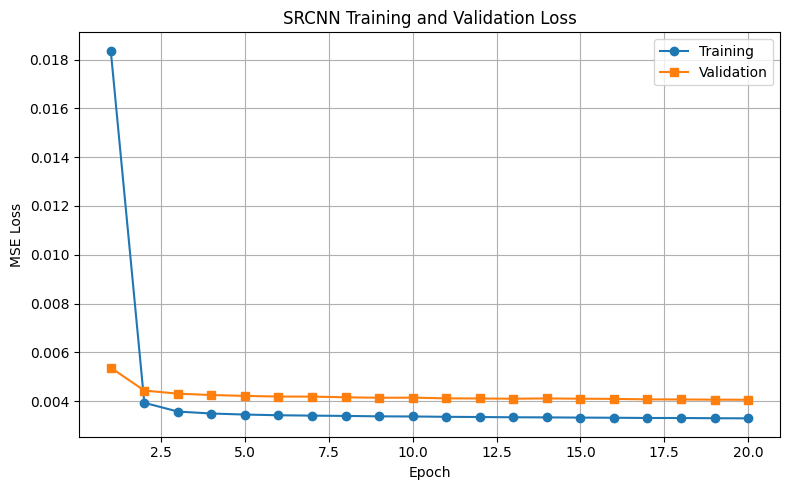

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs+1),
    train_loss_history,
    marker="o",
    label="Training"
)

plt.plot(
    range(1, epochs+1),
    val_loss_history,
    marker="s",
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title(
    "SRCNN Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../results/srcnn/training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
best_model = SRCNN().to(
    device
)

best_model.load_state_dict(
    torch.load(
        "../models/srcnn/srcnn_best.pth",
        map_location=device
    )
)

best_model.eval()

print(
    "Best SRCNN model loaded"
)

Best SRCNN model loaded


/tmp/ipykernel_1983468/2877334665.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


In [22]:
psnr_scores = []
ssim_scores = []
mse_scores = []

best_model.eval()


with torch.no_grad():

    for i, (
        input_img,
        gt_img
    ) in enumerate(
        tqdm(test_loader)
    ):

        input_img = input_img.to(
            device
        )

        output = best_model(
            input_img
        )

        output = torch.clamp(
            output,
            0,
            1
        )


        restored = (
            output
            .squeeze()
            .cpu()
            .numpy()
        )


        gt = (
            gt_img
            .squeeze()
            .numpy()
        )


        # =================
        # METRICS
        # =================

        psnr = peak_signal_noise_ratio(
            gt,
            restored,
            data_range=1
        )

        ssim = structural_similarity(
            gt,
            restored,
            data_range=1
        )

        mse = mean_squared_error(
            gt,
            restored
        )


        psnr_scores.append(
            psnr
        )

        ssim_scores.append(
            ssim
        )

        mse_scores.append(
            mse
        )


        # =================
        # SAVE .NPY
        # =================

        filename = test_files[i]

        np.save(
            os.path.join(
                OUTPUT_PATH,
                filename
            ),
            restored
        )


print(
    "SRCNN testing completed"
)

100%|██████████| 320/320 [00:05<00:00, 59.77it/s]

SRCNN testing completed


In [23]:
avg_psnr = np.mean(
    psnr_scores
)

avg_ssim = np.mean(
    ssim_scores
)

avg_mse = np.mean(
    mse_scores
)


print(
    "Average PSNR:",
    avg_psnr
)

print(
    "Average SSIM:",
    avg_ssim
)

print(
    "Average MSE:",
    avg_mse
)

Average PSNR: 27.52943205674495
Average SSIM: 0.7250710888767316
Average MSE: 0.0027344456903774946


In [24]:
metrics_file = os.path.join(
    RESULT_PATH,
    "metrics.txt"
)

with open(
    metrics_file,
    "w"
) as f:

    f.write(
        "Experiment: SRCNN Baseline\n"
    )

    f.write(
        "==========================\n\n"
    )

    f.write(
        "Dataset: KLA Semiconductor Image Restoration\n\n"
    )

    f.write(
        f"Training samples: {len(train_files)}\n"
    )

    f.write(
        f"Validation samples: {len(val_files)}\n"
    )

    f.write(
        f"Testing samples: {len(test_files)}\n\n"
    )

    f.write(
        "Input: NoisyLR 128x128\n"
    )

    f.write(
        "Preprocessing: Bicubic upsampling to 256x256\n"
    )

    f.write(
        "Output: SRCNN restored 256x256\n\n"
    )

    f.write(
        "Performance Metrics\n"
    )

    f.write(
        "-------------------\n"
    )

    f.write(
        f"Average PSNR: {avg_psnr:.6f} dB\n"
    )

    f.write(
        f"Average SSIM: {avg_ssim:.6f}\n"
    )

    f.write(
        f"Average MSE: {avg_mse:.10f}\n"
    )

    f.write(
        f"Model Parameters: {total_params}\n"
    )


print(
    "SRCNN metrics saved"
)

SRCNN metrics saved


In [25]:
metrics_df = pd.DataFrame({

    "Filename":
        test_files,

    "PSNR":
        psnr_scores,

    "SSIM":
        ssim_scores,

    "MSE":
        mse_scores
})

metrics_df.to_csv(
    "../results/srcnn/per_image_metrics.csv",
    index=False
)

metrics_df.head()

,Filename,PSNR,SSIM,MSE
0,001218.npy,27.140071,0.772622,0.001932
1,001158.npy,27.837962,0.522099,0.001645
2,001415.npy,21.040987,0.695876,0.007869
3,002896.npy,28.371342,0.779577,0.001455
4,001527.npy,34.403010,0.870581,0.000363


In [26]:
PNG_PATH = (
    "../results/srcnn/images"
)

os.makedirs(
    PNG_PATH,
    exist_ok=True
)

print(
    "PNG folder created"
)

PNG folder created


In [27]:
restored_files = sorted([
    f for f in os.listdir(
        OUTPUT_PATH
    )
    if f.endswith(".npy")
])

print(
    "SRCNN restored files:",
    len(restored_files)
)


for f in tqdm(restored_files):

    img = np.load(
        os.path.join(
            OUTPUT_PATH,
            f
        )
    )

    save_name = f.replace(
        ".npy",
        ".png"
    )

    plt.imsave(
        os.path.join(
            PNG_PATH,
            save_name
        ),
        img,
        cmap="gray"
    )


print(
    "All SRCNN PNG images saved"
)

SRCNN restored files: 320


100%|██████████| 320/320 [00:06<00:00, 48.90it/s]

All SRCNN PNG images saved


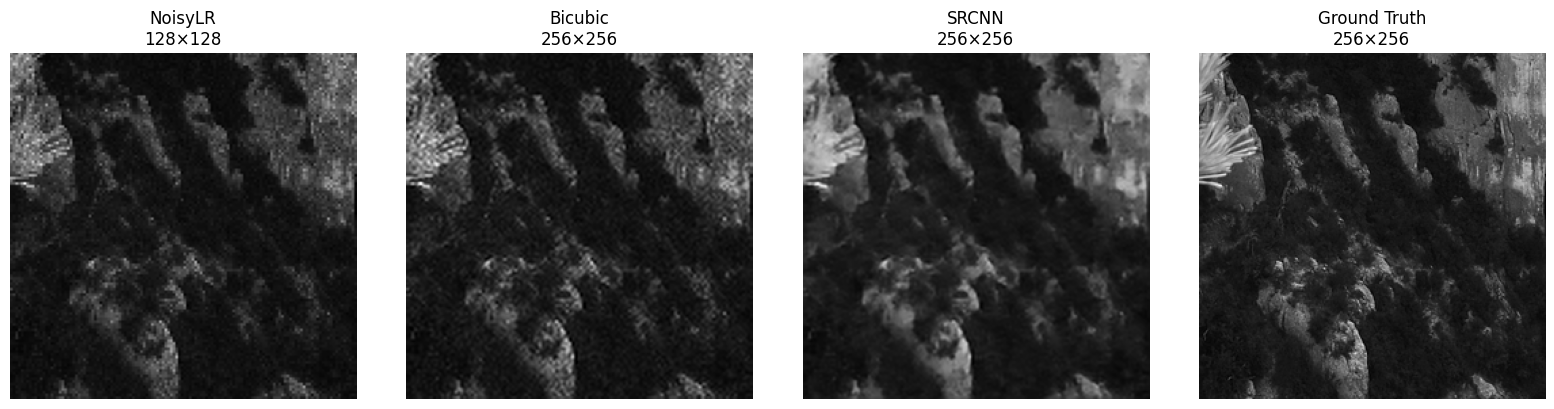

In [28]:
idx = test_files[0]

gt = np.load(
    os.path.join(
        GT_PATH,
        idx
    )
)

noisy = np.load(
    os.path.join(
        NOISY_PATH,
        idx
    )
)

bicubic = resize(
    noisy,
    gt.shape,
    order=3,
    anti_aliasing=True,
    preserve_range=True
)

srcnn = np.load(
    os.path.join(
        OUTPUT_PATH,
        idx
    )
)


plt.figure(
    figsize=(16,4)
)


plt.subplot(1,4,1)

plt.imshow(
    noisy,
    cmap="gray"
)

plt.title(
    "NoisyLR\n128×128"
)

plt.axis("off")


plt.subplot(1,4,2)

plt.imshow(
    bicubic,
    cmap="gray"
)

plt.title(
    "Bicubic\n256×256"
)

plt.axis("off")


plt.subplot(1,4,3)

plt.imshow(
    srcnn,
    cmap="gray"
)

plt.title(
    "SRCNN\n256×256"
)

plt.axis("off")


plt.subplot(1,4,4)

plt.imshow(
    gt,
    cmap="gray"
)

plt.title(
    "Ground Truth\n256×256"
)

plt.axis("off")


plt.tight_layout()

plt.savefig(
    "../results/srcnn/comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
bicubic_psnr = []
bicubic_ssim = []
bicubic_mse = []


for f in tqdm(test_files):

    gt = np.load(
        os.path.join(
            GT_PATH,
            f
        )
    )

    noisy = np.load(
        os.path.join(
            NOISY_PATH,
            f
        )
    )

    restored = resize(
        noisy,
        gt.shape,
        order=3,
        anti_aliasing=True,
        preserve_range=True
    )


    bicubic_psnr.append(
        peak_signal_noise_ratio(
            gt,
            restored,
            data_range=1
        )
    )


    bicubic_ssim.append(
        structural_similarity(
            gt,
            restored,
            data_range=1
        )
    )


    bicubic_mse.append(
        mean_squared_error(
            gt,
            restored
        )
    )


print(
    "Bicubic PSNR:",
    np.mean(bicubic_psnr)
)

print(
    "SRCNN PSNR:",
    avg_psnr
)

print()

print(
    "Bicubic SSIM:",
    np.mean(bicubic_ssim)
)

print(
    "SRCNN SSIM:",
    avg_ssim
)

print()

print(
    "Bicubic MSE:",
    np.mean(bicubic_mse)
)

print(
    "SRCNN MSE:",
    avg_mse
)

100%|██████████| 320/320 [00:03<00:00, 97.98it/s]

Bicubic PSNR: 22.478415628140233
SRCNN PSNR: 27.52943205674495

Bicubic SSIM: 0.5116624465067319
SRCNN SSIM: 0.7250710888767316

Bicubic MSE: 0.007338321273890881
SRCNN MSE: 0.0027344456903774946


In [30]:
comparison_df = pd.DataFrame({

    "Method": [
        "Bicubic",
        "SRCNN"
    ],

    "PSNR_dB": [
        np.mean(
            bicubic_psnr
        ),
        avg_psnr
    ],

    "SSIM": [
        np.mean(
            bicubic_ssim
        ),
        avg_ssim
    ],

    "MSE": [
        np.mean(
            bicubic_mse
        ),
        avg_mse
    ]
})


comparison_df.to_csv(
    "../results/srcnn/baseline_comparison.csv",
    index=False
)

comparison_df

,Method,PSNR_dB,SSIM,MSE
0,Bicubic,22.478416,0.511662,0.007338
1,SRCNN,27.529432,0.725071,0.002734


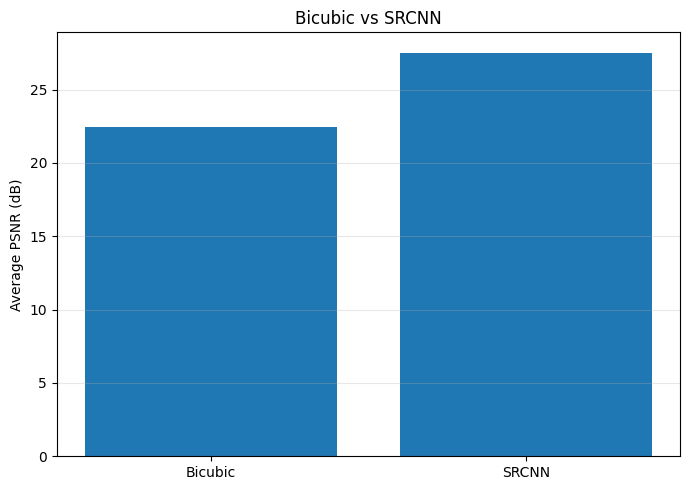

In [31]:
plt.figure(
    figsize=(7,5)
)

plt.bar(
    comparison_df["Method"],
    comparison_df["PSNR_dB"]
)

plt.ylabel(
    "Average PSNR (dB)"
)

plt.title(
    "Bicubic vs SRCNN"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../results/srcnn/psnr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

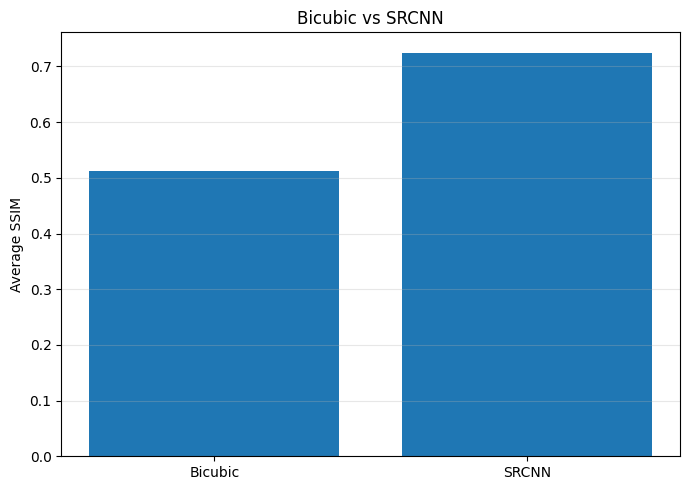

In [32]:
plt.figure(
    figsize=(7,5)
)

plt.bar(
    comparison_df["Method"],
    comparison_df["SSIM"]
)

plt.ylabel(
    "Average SSIM"
)

plt.title(
    "Bicubic vs SRCNN"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../results/srcnn/ssim_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
import shutil

EXAMPLE_PATH = (
    "../results/srcnn/examples"
)

os.makedirs(
    EXAMPLE_PATH,
    exist_ok=True
)

sample_files = (
    test_files[:5]
)

for f in sample_files:

    png_name = f.replace(
        ".npy",
        ".png"
    )

    shutil.copy(
        os.path.join(
            PNG_PATH,
            png_name
        ),
        EXAMPLE_PATH
    )

print(
    "Example SRCNN images copied"
)

Example SRCNN images copied


In [34]:
print(
    "===== SRCNN RESULTS ====="
)

print(
    "Best model:",
    os.path.exists(
        "../models/srcnn/srcnn_best.pth"
    )
)

print(
    "Final model:",
    os.path.exists(
        "../models/srcnn/srcnn_final.pth"
    )
)

print(
    "Metrics:",
    os.path.exists(
        "../results/srcnn/metrics.txt"
    )
)

print(
    "Comparison:",
    os.path.exists(
        "../results/srcnn/comparison.png"
    )
)

print(
    "Restored NPY:",
    len(
        os.listdir(
            OUTPUT_PATH
        )
    )
)

print(
    "PNG images:",
    len(
        os.listdir(
            PNG_PATH
        )
    )
)

===== SRCNN RESULTS =====
Best model: True
Final model: True
Metrics: True
Comparison: True
Restored NPY: 320
PNG images: 320
